# 📈 NEWTON TOOLS — Cinemática 1D
---
Copyright (C) 2026 Roberto Baginski Batista Santos - Prof.Baginski@gmail.com

Este programa é um software livre; você pode redistribuí-lo e/ou
modificá-lo sob os termos da Licença Pública Geral GNU como publicada
pela Free Software Foundation; tanto a versão 3 da Licença, ou
(a seu critério) qualquer versão posterior.

Este programa é distribuído na expectativa de que seja útil,
mas SEM NENHUMA GARANTIA; sem mesmo a garantia implícita de
COMERCIALIZAÇÃO ou de ADEQUAÇÃO A QUALQUER PROPÓSITO EM PARTICULAR.
Veja a Licença Pública Geral GNU para mais detalhes.

Você deve ter recebido uma cópia da Licença Pública Geral GNU junto
com este programa. Se não, veja https://www.gnu.org/licenses/gpl-3.0.html.

---
Esta ferramenta permite analisar o movimento retilíneo de um corpo a partir de uma das seguintes funções horárias:
-  **Posição** $x(t)$
-  **Velocidade** $v(t)$
-  **Aceleração** $a(t)$

no intervalo de tempo entre $t_\mathrm{min}$ e $t_\mathrm{max}$, cujos valores devem ser informados.

Caso você escolha iniciar pela velocidade ou pela aceleração, haverá campos para informar as condições iniciais $x_0=x(t_\mathrm{min})$ e $v_0=v(t_\mathrm{min})$.

---
**Como usar:**
Execute a **Célula 1** — a interface aparece logo abaixo.
---
### Sintaxe da equação

A variável independente é `t`. A equação horária deve ser digitada usando a notação do pacote SymPy (https://www.sympy.org/):

| Para obter &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; | Digite &nbsp; &nbsp; &nbsp; &nbsp; |
|:---|:---|
| $- 5.7t^2$ | `-5.7*t**2` |
| $\sqrt{t/2}$ | `sqrt(t/2)` |
| $e^{-2t}$ | `exp(-2*t)` |
| $\ln(2t^3)$ | `log(2*t**3)` |
| $\log_{10}(2t^3)$ | `log(2*t**3, 10)` |
| $\sin(2\pi t)$ | `sin(2*pi*t)` |
| $\cos(2\pi t)$ | `cos(2*pi*t)` |
| $6.626\times 10^{-34}$ | `6.626*10**-34` |


1. **Evite usar o símbolo `I`**, porque `I` é reservado pelo SymPy para representar a unidade imaginária $i=\sqrt{-1}$.
2. **Evite usar o símbolo `E`**, porque `E` é reservado pelo SymPy para representar a base do logaritmo natural $e=\exp(1)$.
3. Além disso, os símbolos `S`, `N`, `C`, `O`, `Q`, `zoo`, `nan`, `oo`, `true`, `false`, `True` e `False` não devem ser usados, porque também são símbolos reservados pelo SimPy.

---
**Atenção**: os campos de unidades servem apenas para rotular eixos e tabelas e não realizam conversão entre unidades. Cabe a você garantir que a função digitada use as unidades corretamente.

---
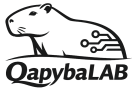  
**https://github.com/rbaginski/QapybaLAB**

In [ ]:
#@title Execute esta célula para abrir a ferramenta **NEWTON TOOLS &mdash; Cinemática 1D**
# ── Célula 1: Cinemática 1D ───────────────────────────────
# A ferramenta foi especificada pelo licenciante, incluindo modelos, métodos,
# pacotes a serem usados e linhas gerais da inteface gráfica, mas a maior parte
# do código, especialmente as funções para leitura de arquivos e para a
# interface gráfica, foi escrita usando o modelo Claude Sonnet 4.6.
# O código gerado foi inspecionado e sofreu diversas alterações e correções
# realizadas pelo licenciante e pelo modelo Gemini 3.5-flash.

import math, io, base64, warnings
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sympy.parsing.sympy_parser import (
    parse_expr, standard_transformations, implicit_multiplication_application
)
from scipy.optimize import brentq
import ipywidgets as w
from IPython.display import display, HTML, Math, clear_output
import zipfile

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 10,
                             "axes.spines.top": False,
                             "axes.spines.right": False})

# Variável simbólica do tempo
t = sp.symbols('t', real=True)

# Transformações para aceitar entradas como "2t" (multiplicação implícita)
TRANSFORMATIONS = standard_transformations + (implicit_multiplication_application,)

# Detecta se está rodando no Google Colab (para usar o download automático de arquivos)
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ══════════════════════════════════════════════════════════════════
#  ESTILOS CSS
#  Convenção compartilhada por toda a suíte LAB/NEWTON TOOLS:
#    .sec   → rótulo de seção (cor = acento do app)
#    .rcard → card de resultado/destaque (cor = acento do app)
#    .gcard → card de "sucesso" (verde fixo)
#    .bcard → card informativo secundário (azul fixo)
#    .wcard → card de aviso (laranja fixo)
#    .ecard → card de erro (vermelho fixo)
#    .icard → card informativo auxiliar (violeta fixo)
#    .res-t → tabela de dados (cabeçalho azul-marinho fixo)
#  Acento desta ferramenta: ciano #1098ad
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<style>
.sec{font-weight:700;font-size:.75rem;letter-spacing:.08em;color:#1098ad;
  text-transform:uppercase;margin:13px 0 3px;}
.rcard{background:#eafcff;border-left:4px solid #1098ad;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.91rem;}
.gcard{background:#f0fff4;border-left:4px solid #2f9e44;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.bcard{background:#f0f4ff;border-left:4px solid #3b5bdb;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.91rem;}
.wcard{background:#fff9db;border-left:4px solid #e67700;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.ecard{background:#fff0f0;border-left:4px solid #c92a2a;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.icard{background:#f3f0ff;border-left:4px solid #7048e8;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.88rem;}
.res-t{border-collapse:collapse;font-size:.83rem;width:40%;margin:6px 0;}
.res-t th{background:#1a1a2e;color:#fff;padding:5px 10px;text-align:left;}
.res-t td{padding:4px 10px;text-align:left;border-bottom:1px solid #eee;
  font-family:monospace;}
.res-t tr:nth-child(odd) td{text-align:left}
.res-t tr:nth-child(even) td{background:#eafcff;text-align:left}
</style>
"""))

# ══════════════════════════════════════════════════════════════════
#  HTML HELPERS
# ══════════════════════════════════════════════════════════════════
def h(tag, content, **attrs):
    a = " ".join(f'{k.rstrip("_")}="{v}"' for k, v in attrs.items())
    return f"<{tag} {a}>{content}</{tag}>"

def card(s, c="rcard"): return f'<div class="{c}">{s}</div>'

def sec_html(texto, estilo=""):
    """Constrói o HTML de um rótulo de seção (classe .sec)."""
    extra = f' style="{estilo}"' if estilo else ""
    return f'<div class="sec"{extra}>{texto}</div>'

def titulo_secao(texto, estilo=""):
    """Widget HTML com um rótulo de seção — forma padrão de criar
    títulos de seção em toda a suíte LAB/NEWTON TOOLS."""
    return w.HTML(sec_html(texto, estilo))

def tabela_html(df):
    """Renderiza um DataFrame com o mesmo estilo .res-t usado nas
    demais ferramentas da suíte."""
    return df.to_html(classes="res-t", index=False, border=0,
                       float_format=lambda v: f"{v:.6g}")

def fig_para_html(fig):
    """Converte uma figura matplotlib em <img> embutido (PNG base64),
    no mesmo padrão visual usado nas demais ferramentas da suíte.
    Não fecha a figura — ela é reutilizada na exportação em PNG."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight")
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode()
    return (f'<img src="data:image/png;base64,{b64}" '
            f'style="width:100%;max-width:900px;border-radius:6px;'
            f'box-shadow:0 2px 8px rgba(0,0,0,.13)">')


def safe_eval(expr, ts):
    '''Avalia uma expressão simbólica em um array de tempos, tratando expressões constantes.'''
    if expr.free_symbols == set():
        val = float(expr)
        return np.full_like(ts, val, dtype=float)
    f = sp.lambdify(t, expr, 'numpy')
    y = np.asarray(f(ts), dtype=float)
    if y.shape != ts.shape:
        y = np.full_like(ts, float(y))
    return y


def find_roots_numeric(expr, tmin, tmax, n=4000, tol=1e-10):
    '''Encontra raízes reais de `expr` no intervalo [tmin, tmax] por varredura + bisseção.'''
    if expr.free_symbols == set():
        return []

    f = sp.lambdify(t, expr, 'numpy')
    ts = np.linspace(tmin, tmax, n)
    ys = np.asarray(f(ts), dtype=float)

    def f_scalar(tv):
        return float(f(tv))

    roots = []
    for i in range(len(ts) - 1):
        y0, y1 = ys[i], ys[i + 1]
        if y0 == 0:
            roots.append(ts[i])
        elif np.isfinite(y0) and np.isfinite(y1) and y0 * y1 < 0:
            try:
                r = brentq(f_scalar, ts[i], ts[i + 1], xtol=tol)
                roots.append(r)
            except Exception:
                pass
    if ys[-1] == 0:
        roots.append(ts[-1])

    roots = sorted(roots)
    merged = []
    for r in roots:
        if not merged or abs(r - merged[-1]) > 1e-6:
            merged.append(r)
    return merged


def tabela_zeros(expr, nome, tmin, tmax):
    '''Tabela com os instantes em que `expr` se anula no intervalo dado.'''
    if expr.free_symbols == set():
        val = float(expr)
        if abs(val) < 1e-12:
            return pd.DataFrame({'Observação': [f'{nome}(t) é identicamente nula em todo o intervalo']})
        return pd.DataFrame({'Observação': [f'{nome}(t) é constante e igual a {val:.6g} (nunca se anula)']})

    f = sp.lambdify(t, expr, 'numpy')
    roots = find_roots_numeric(expr, tmin, tmax)
    if not roots:
        return pd.DataFrame({'Observação': [f'{nome}(t) não se anula no intervalo considerado']})

    rows = [{'t': round(r, 6), f'{nome}(t)': round(float(f(r)), 6)} for r in roots]
    return pd.DataFrame(rows)


def tabela_extremos(expr, nome, tmin, tmax):
    '''Tabela com os pontos de máximo/mínimo local de `expr` no intervalo dado.'''
    d_expr = sp.diff(expr, t)

    if d_expr.free_symbols == set():
        return pd.DataFrame({'Observação': [f'{nome}(t) não possui pontos de extremo local (derivada constante)']})

    dd_expr = sp.diff(d_expr, t)
    f = sp.lambdify(t, expr, 'numpy')
    dd = sp.lambdify(t, dd_expr, 'numpy')

    crit = find_roots_numeric(d_expr, tmin, tmax)
    if not crit:
        return pd.DataFrame({'Observação': [f'Nenhum ponto crítico de {nome}(t) encontrado no intervalo']})

    rows = []
    for c in crit:
        val = float(f(c))
        try:
            ddv = float(dd(c))
        except Exception:
            ddv = 0.0
        if ddv > 1e-9:
            tipo = 'Mínimo local'
        elif ddv < -1e-9:
            tipo = 'Máximo local'
        else:
            tipo = 'Inconclusivo (2ª derivada ≈ 0)'
        rows.append({'t': round(c, 6), f'{nome}(t)': round(val, 6), 'Tipo': tipo})

    return pd.DataFrame(rows)


def calcular_movimento(expr_input, tipo, x0, v0, tmin):
    '''Dada a expressão digitada e o tipo (Posição/Velocidade/Aceleração), retorna (x, v, a).'''
    if tipo == 'Posição':
        x_expr = sp.simplify(expr_input)
        v_expr = sp.simplify(sp.diff(x_expr, t))
        a_expr = sp.simplify(sp.diff(v_expr, t))
    elif tipo == 'Velocidade':
        v_expr = sp.simplify(expr_input)
        a_expr = sp.simplify(sp.diff(v_expr, t))
        C = x0 - sp.integrate(v_expr, t).subs(t, tmin)
        x_expr = sp.simplify(sp.integrate(v_expr, t) + C)
    else:  # Aceleração
        a_expr = sp.simplify(expr_input)
        Cv = v0 - sp.integrate(a_expr, t).subs(t, tmin)
        v_expr = sp.simplify(sp.integrate(a_expr, t) + Cv)
        Cx = x0 - sp.integrate(v_expr, t).subs(t, tmin)
        x_expr = sp.simplify(sp.integrate(v_expr, t) + Cx)
    return x_expr, v_expr, a_expr


# ----------------------- Cabeçalho -----------------------

cabecalho = w.HTML(r'''
<div style="background: linear-gradient(135deg, #004587 0%, #00AB45 80%, #006EAB 100%);
            padding: 14px 20px; border-radius: 10px; color: white;
            font-family: 'Segoe UI', Arial, sans-serif; margin-bottom: 12px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.15);">
  <div style="font-size: 13px; letter-spacing: 3px; opacity: 0.85; font-weight: 600;">QapybaLAB &mdash; NEWTON TOOLS</div>
  <div style="font-size: 26px; font-weight: 700; margin-top: 2px;">📈 Cinemática 1D</div>
</div>
''')


# ----------------------- Widgets de entrada -----------------------

tipo_radio = w.RadioButtons(
    options=['Posição', 'Velocidade', 'Aceleração'],
    value='Posição',
    description='Escolha:',
    style={'description_width': 'initial'}
)

funcao_text = w.Text(
    value='10*t - 5*t**2',
    description='x(t) =',
    style={'description_width': 'initial'},
    layout=w.Layout(width='480px')
)

x0_text = w.FloatText(
    value=0.0, description='Posição inicial x₀ (em t = t_min):',
    style={'description_width': 'initial'}, layout=w.Layout(width='320px', display='none')
)

v0_text = w.FloatText(
    value=0.0, description='Velocidade inicial v₀ (em t = t_min):',
    style={'description_width': 'initial'}, layout=w.Layout(width='320px', display='none')
)

tmin_text = w.FloatText(value=0.0, description='t mínimo:',
                               style={'description_width': 'initial'}, layout=w.Layout(width='180px'))
tmax_text = w.FloatText(value=10.0, description='t máximo:',
                               style={'description_width': 'initial'}, layout=w.Layout(width='180px'))

unidade_pos = w.Text(value='m', description='Unidade de posição:',
                            style={'description_width': 'initial'}, layout=w.Layout(width='200px'))
unidade_tempo = w.Text(value='s', description='Unidade de tempo:',
                              style={'description_width': 'initial'}, layout=w.Layout(width='200px'))

calcular_btn = w.Button(description='▶  Calcular', button_style='primary', icon='calculator',
                        layout=w.Layout(width='160px', height='36px'))

export_png_btn = w.Button(description='Gráficos (PNG)', icon='image')
export_xlsx_btn = w.Button(description='Exportar XLSX', icon='file-excel')
export_csv_btn = w.Button(description='Exportar CSV', icon='file-text')

out_expr = w.Output()
out_plot = w.Output()
out_tables = w.Output()
out_export = w.Output()


def atualizar_visibilidade(change=None):
    tipo = tipo_radio.value
    if tipo == 'Posição':
        x0_text.layout.display = 'none'
        v0_text.layout.display = 'none'
        funcao_text.description = 'x(t) ='
    elif tipo == 'Velocidade':
        x0_text.layout.display = ''
        v0_text.layout.display = 'none'
        funcao_text.description = 'v(t) ='
    else:
        x0_text.layout.display = ''
        v0_text.layout.display = ''
        funcao_text.description = 'a(t) ='


tipo_radio.observe(atualizar_visibilidade, names='value')
atualizar_visibilidade()



# ----------------------- Lógica principal -----------------------

# Dicionário usado para guardar os resultados do último cálculo (para exportação)
state = {}


def on_calcular_clicked(btn=None):
    for o in (out_expr, out_plot, out_tables, out_export):
        o.clear_output()

    tmin = tmin_text.value
    tmax = tmax_text.value
    up = unidade_pos.value.strip() or 'm'
    ut = unidade_tempo.value.strip() or 's'

    if tmin >= tmax:
        with out_expr:
            display(HTML(card('✘ O tempo mínimo deve ser menor que o tempo máximo.', 'ecard')))
        return

    # --- Interpreta a expressão digitada ---
    try:
        expr_input = parse_expr(funcao_text.value, local_dict={'t': t}, transformations=TRANSFORMATIONS)
    except Exception as e:
        with out_expr:
            display(HTML(card(f'✘ Erro ao interpretar a função: {e}', 'ecard')))
        return

    # --- Calcula x(t), v(t) e a(t) por derivação/integração ---
    try:
        x_expr, v_expr, a_expr = calcular_movimento(
            expr_input, tipo_radio.value, x0_text.value, v0_text.value, tmin
        )
    except Exception as e:
        with out_expr:
            display(HTML(card(f'✘ Erro ao calcular derivadas/integrais: {e}', 'ecard')))
        return

    state.clear()
    state.update(x_expr=x_expr, v_expr=v_expr, a_expr=a_expr, tmin=tmin, tmax=tmax, up=up, ut=ut)

    # --- Exibe as expressões ---
    with out_expr:
        display(Math(r'x(t) = ' + sp.latex(x_expr)))
        display(Math(r'v(t) = ' + sp.latex(v_expr)))
        display(Math(r'a(t) = ' + sp.latex(a_expr)))
        if tipo_radio.value != 'Posição':
            display(HTML(card(
                'ℹ As constantes de integração foram calculadas a partir '
                'das condições iniciais informadas.', 'icard')))

    # --- Calcula valores numéricos para os gráficos ---
    ts = np.linspace(tmin, tmax, 500)
    xs = safe_eval(x_expr, ts)
    vs = safe_eval(v_expr, ts)
    as_ = safe_eval(a_expr, ts)
    state.update(ts=ts, xs=xs, vs=vs, as_=as_)

    # --- Tabelas de zeros e extremos ---
    tabelas = {
        'Zeros_posicao': tabela_zeros(x_expr, 'x', tmin, tmax),
        'Extremos_posicao': tabela_extremos(x_expr, 'x', tmin, tmax),
        'Zeros_velocidade': tabela_zeros(v_expr, 'v', tmin, tmax),
        'Extremos_velocidade': tabela_extremos(v_expr, 'v', tmin, tmax),
        'Zeros_aceleracao': tabela_zeros(a_expr, 'a', tmin, tmax),
        'Extremos_aceleracao': tabela_extremos(a_expr, 'a', tmin, tmax),
    }
    state['tabelas'] = tabelas

    # --- Gráficos (matplotlib) ---
    fig, axs = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
    cores = {'pos': '#1565c0', 'vel': '#ef6c00', 'ace': '#2e7d32'}

    axs[0].plot(ts, xs, color=cores['pos'], lw=2, label='x(t)')
    axs[1].plot(ts, vs, color=cores['vel'], lw=2, label='v(t)')
    axs[2].plot(ts, as_, color=cores['ace'], lw=2, label='a(t)')

    # marca os zeros e extremos sobre cada curva
    def marcar(ax, df, col_y, cor):
        if 't' not in df.columns:
            return
        if col_y in df.columns:
            ax.scatter(df['t'], df[col_y], color=cor, zorder=5, s=40,
                       edgecolor='black', linewidth=0.6)

    marcar(axs[0], tabelas['Zeros_posicao'], 'x(t)', 'white')
    marcar(axs[0], tabelas['Extremos_posicao'], 'x(t)', cores['pos'])
    marcar(axs[1], tabelas['Zeros_velocidade'], 'v(t)', 'white')
    marcar(axs[1], tabelas['Extremos_velocidade'], 'v(t)', cores['vel'])
    marcar(axs[2], tabelas['Zeros_aceleracao'], 'a(t)', 'white')
    marcar(axs[2], tabelas['Extremos_aceleracao'], 'a(t)', cores['ace'])

    axs[0].set_ylabel(f'x(t)  [{up}]')
    axs[1].set_ylabel(f'v(t)  [{up}/{ut}]')
    axs[2].set_ylabel(f'a(t)  [{up}/{ut}²]')
    axs[2].set_xlabel(f't  [{ut}]')

    for ax, titulo in zip(axs, ['Posição', 'Velocidade', 'Aceleração']):
        ax.set_title(titulo, fontsize=11, color='#1565c0', loc='left')
        ax.grid(True, alpha=0.3)

    fig.suptitle('Cinemática em 1D', fontsize=14, fontweight='bold', color='#0d47a1')
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    state['fig'] = fig

    with out_plot:
        display(HTML(fig_para_html(fig)))
    plt.close(fig)

    # --- Exibição das tabelas ---
    with out_tables:
        display(HTML(sec_html('A) Pontos em que a posição é nula', 'margin-top:8px')))
        display(HTML(tabela_html(tabelas['Zeros_posicao'])))
        display(HTML(sec_html('B) Pontos de mínimo e máximo locais da posição', 'margin-top:8px')))
        display(HTML(tabela_html(tabelas['Extremos_posicao'])))
        display(HTML(sec_html('C) Pontos em que a velocidade é nula', 'margin-top:8px')))
        display(HTML(tabela_html(tabelas['Zeros_velocidade'])))
        display(HTML(sec_html('D) Pontos de mínimo e máximo locais da velocidade', 'margin-top:8px')))
        display(HTML(tabela_html(tabelas['Extremos_velocidade'])))
        display(HTML(sec_html('E) Pontos em que a aceleração é nula', 'margin-top:8px')))
        display(HTML(tabela_html(tabelas['Zeros_aceleracao'])))
        display(HTML(sec_html('F) Pontos de mínimo e máximo locais da aceleração', 'margin-top:8px')))
        display(HTML(tabela_html(tabelas['Extremos_aceleracao'])))

    with out_export:
        display(HTML(card(
            '✔ Cálculo concluído. Use os botões abaixo para exportar os resultados.',
            'gcard')))


# ----------------------- Exportação -----------------------

def _baixar(caminho):
    if IN_COLAB:
        colab_files.download(caminho)
    else:
        display(HTML(card(f'Arquivo salvo em: <code>{caminho}</code>', 'icard')))


def on_export_png(btn=None):
    with out_export:
        if 'fig' not in state:
            display(HTML(card('⚠ Calcule os resultados antes de exportar.', 'wcard')))
            return
        caminho = '/content/movimento_1d.png'
        state['fig'].savefig(caminho, dpi=150, bbox_inches='tight')
        display(HTML(card(f'✔ Gráficos exportados: <code>{caminho}</code>', 'gcard')))
        _baixar(caminho)


def on_export_xlsx(btn=None):
    with out_export:
        if 'tabelas' not in state:
            display(HTML(card('⚠ Calcule os resultados antes de exportar.', 'wcard')))
            return
        caminho = '/content/movimento_1d_dados.xlsx'
        with pd.ExcelWriter(caminho) as writer:
            for nome, df in state['tabelas'].items():
                df.to_excel(writer, sheet_name=nome[:31], index=False)
            up_, ut_ = state.get('up','m'), state.get('ut','s')
            df_dados = pd.DataFrame({
                f't [{ut_}]': state['ts'],
                f'x(t) [{up_}]': state['xs'],
                f'v(t) [{up_}/{ut_}]': state['vs'],
                f'a(t) [{up_}/{ut_}²]': state['as_']
            })
            df_dados.to_excel(writer, sheet_name='Dados_t_x_v_a', index=False)
        display(HTML(card(f'✔ Tabelas e dados exportados: <code>{caminho}</code>', 'gcard')))
        _baixar(caminho)


def on_export_csv(btn=None):
    with out_export:
        if 'tabelas' not in state:
            display(HTML(card('⚠ Calcule os resultados antes de exportar.', 'wcard')))
            return
        caminho = '/content/movimento_1d_dados_csv.zip'
        with zipfile.ZipFile(caminho, 'w') as zf:
            for nome, df in state['tabelas'].items():
                zf.writestr(f'{nome}.csv', df.to_csv(index=False))
            up_, ut_ = state.get('up','m'), state.get('ut','s')
            df_dados = pd.DataFrame({
                f't [{ut_}]': state['ts'],
                f'x(t) [{up_}]': state['xs'],
                f'v(t) [{up_}/{ut_}]': state['vs'],
                f'a(t) [{up_}/{ut_}²]': state['as_']
            })
            zf.writestr('Dados_t_x_v_a.csv', df_dados.to_csv(index=False))
        display(HTML(card(
            f'✔ Tabelas e dados exportados (ZIP com CSVs): <code>{caminho}</code>',
            'gcard')))
        _baixar(caminho)


calcular_btn.on_click(on_calcular_clicked)
export_png_btn.on_click(on_export_png)
export_xlsx_btn.on_click(on_export_xlsx)
export_csv_btn.on_click(on_export_csv)


# ----------------------- Interface -----------------------

ui = w.VBox([
    cabecalho,

    titulo_secao('⚙️ Parâmetros do movimento'),
    tipo_radio,
    funcao_text,
    w.HBox([x0_text, v0_text]),
    w.HBox([tmin_text, tmax_text]),
    w.HBox([unidade_pos, unidade_tempo]),
    calcular_btn,

    titulo_secao('📋 Expressões'),
    out_expr,

    titulo_secao('📊 Gráficos'),
    out_plot,

    titulo_secao('🔎 Tabelas de pontos notáveis'),
    out_tables,

    titulo_secao('💾 Exportar resultados'),
    w.HBox([export_png_btn, export_xlsx_btn, export_csv_btn]),
    out_export,
])

display(ui)